# Wasserstein over Wasserstein for three-component Gaussian mixtures

This notebook generates `fig:kantorovich-wow-mixtures`.  A three-component
Gaussian mixture can be viewed either as a collapsed density on the line, or as
a discrete law over Gaussian components equipped with the Bures--Wasserstein
metric.  The two interpolations agree only in special cases: component-level
transport moves matched Gaussian atoms, whereas the true one-dimensional $W_2$
geodesic is linear in quantile coordinates.


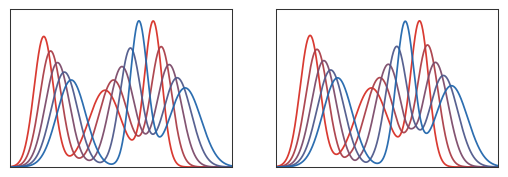

In [1]:

from pathlib import Path
import sys

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        NOTEBOOK_DIR = candidate.resolve()
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment
from scipy.stats import norm, gaussian_kde
import ot

from figure_style import (
    RED, BLUE, VIOLET, ORANGE, DIRAC_MARKER_SIZE,
    figure_dir, save_pdf, remove_axes, box_axes, setup_matplotlib,
    interp_color, padded_limits,
)

setup_matplotlib()

OUT = figure_dir("kantorovich-wow-mixtures")
THUMB = NOTEBOOK_DIR / "thumbnails" / "kantorovich-wow-mixtures.png"
THUMB.parent.mkdir(exist_ok=True)

weights0 = np.array([1/3, 1/3, 1/3])
means0 = np.array([-1.45, -0.18, 0.82])
sigmas0 = np.array([0.20, 0.34, 0.18])
weights1 = np.array([1/3, 1/3, 1/3])
means1 = np.array([-0.88, 0.52, 1.48])
sigmas1 = np.array([0.30, 0.18, 0.33])
xgrid = np.linspace(-2.45, 2.75, 1800)

def gaussian_pdf(x, m, s):
    return np.exp(-0.5 * ((x - m) / s) ** 2) / (np.sqrt(2 * np.pi) * s)

def mixture_pdf(x, w, m, s):
    return sum(wi * gaussian_pdf(x, mi, si) for wi, mi, si in zip(w, m, s))

def mixture_cdf_values(x, w, m, s):
    return sum(wi * norm.cdf((x - mi) / si) for wi, mi, si in zip(w, m, s))

C = (means0[:, None] - means1[None, :]) ** 2 + (sigmas0[:, None] - sigmas1[None, :]) ** 2
P = ot.emd(weights0, weights1, C)

def component_density(t):
    density = np.zeros_like(xgrid)
    for i in range(len(weights0)):
        for j in range(len(weights1)):
            if P[i, j] > 1e-12:
                m = (1 - t) * means0[i] + t * means1[j]
                s = (1 - t) * sigmas0[i] + t * sigmas1[j]
                density += P[i, j] * gaussian_pdf(xgrid, m, s)
    return density

u = np.linspace(1e-4, 1 - 1e-4, 6000)
cdf0 = mixture_cdf_values(xgrid, weights0, means0, sigmas0)
cdf1 = mixture_cdf_values(xgrid, weights1, means1, sigmas1)
q0 = np.interp(u, cdf0, xgrid)
q1 = np.interp(u, cdf1, xgrid)

def collapsed_density(t):
    samples = (1 - t) * q0 + t * q1
    kde = gaussian_kde(samples, bw_method=0.055)
    return kde(xgrid)

times = np.linspace(0, 1, 5)

def draw_panel(ax, mode):
    ymax = 0.0
    for t in times:
        density = component_density(t) if mode == "component" else collapsed_density(t)
        ymax = max(ymax, float(density.max()))
        ax.plot(xgrid, density, color=interp_color(t), lw=1.25, alpha=0.95)
    ax.set_xlim(-2.15, 2.45)
    ax.set_ylim(0, 1.08 * ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    box_axes(ax)

fig, axs = plt.subplots(1, 2, figsize=(6.3, 2.05))
for ax, mode in zip(axs, ["component", "collapsed"]):
    draw_panel(ax, mode)
    single, single_ax = plt.subplots(figsize=(3.0, 1.8))
    draw_panel(single_ax, mode)
    save_pdf(single, OUT / ("component-level.pdf" if mode == "component" else "collapsed-w2.pdf"), pad_inches=0.035)
    plt.close(single)
fig.savefig(THUMB, dpi=220, bbox_inches="tight", pad_inches=0.04)
plt.show()
